# Week 5: The Machine Learning Lifecycle — From Data to Deployment Decision

**Today's roadmap.** We've covered: AI vs. ML vs. deep learning, supervised vs. unsupervised learning, data types/quality, visualization, statistics, and train/validation/test splits. Today we connect all of it into the full **ML lifecycle**:

1. Problem framing
2. Data preparation
3. Train / test split
4. Model training
5. Model evaluation
6. Deployment decision
7. Monitoring

**How this notebook works.** For each stage, I'll first **demo** it on a sample dataset. Then you'll see a **🔧 Your Turn** section where you'll repeat the same step on your own dataset. Nothing here uses neural networks — we're using the classical models you already understand: logistic regression and decision trees.

> **Before you start:** have a CSV file ready that you want to build a classifier on (e.g., a dataset from an earlier assignment, or one you're using for your final project). It should have a clear target column you're trying to predict (something with two categories works best for this exercise, like yes/no, pass/fail, churn/no churn).

In [1]:
# Run this cell first — it loads the libraries we'll use all notebook long.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

pd.set_option('display.max_columns', 50)
print('Libraries loaded.')

Libraries loaded.


---
## Stage 1 — Problem Framing

Before touching any code, every ML project starts with translating a **business question** into an **ML task**. Recall from Week 2: is this classification, regression, or clustering? What does the organization actually want to *do* with the prediction, and what does a wrong prediction *cost* them?

**Demo problem:** A healthcare provider wants to flag patients whose diagnostic scan results suggest a tumor is malignant, so a specialist can prioritize reviewing that case. This is a **binary classification** problem: malignant (1) vs. benign (0).

### 🔧 Your Turn — Frame your own problem
Before writing any code, answer these in the markdown cell below (double-click it to edit):

1. What is the business/real-world question you're trying to answer?
2. What is your target variable, and what are its possible values?
3. Is this classification or regression?
4. What would a *false positive* cost? What would a *false negative* cost? Which is worse for your case?

**Your answers:**

1.
2.
3.
4.

---
## Stage 2 — Data: Load and Explore

Recall from Weeks 3–4: check structure, data types, missing values, and target balance *before* you model anything. An imbalanced target (e.g., 95% benign / 5% malignant) changes how we should evaluate the model later.

**Demo:** we'll use a built-in diagnostic dataset from scikit-learn so everyone can run this without downloading a file.

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df_demo = data.frame.copy()

print('Shape:', df_demo.shape)
df_demo.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# Check structure, types, and missing values
df_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
# Check target balance -- 'target' is 0 = malignant, 1 = benign in this dataset
df_demo['target'].value_counts(normalize=True)

,proportion
target,
1,0.627417
0,0.372583


### 🔧 Your Turn — Load and explore your dataset
**Load your own CSV file OR Pick one of these binary classification datasets:**


| Dataset | Link | Notes |
|---|---|---|
| Titanic Survival | https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv | Direct CSV link — load straight with `pd.read_csv(url)`. Target column: `Survived`. Has some missing `Age` values and categorical columns (`Sex`, `Embarked`) to handle. |
| Pima Indians Diabetes | https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv | Direct CSV link, but has **no header row** — see the loading code below. Target column: `Outcome`. All numeric, no missing values. |
| Heart Disease (UCI) | https://archive.ics.uci.edu/dataset/45/heart+disease | Download the CSV from this page, then upload it like your own dataset. Target: presence of heart disease. |
| Bank Marketing (UCI) | https://archive.ics.uci.edu/dataset/222/bank+marketing | Download from this page, then upload. Predicts whether a customer subscribes after a marketing call — imbalanced target, good for the precision/recall discussion later. |
| Breast Cancer Wisconsin (UCI) | https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic | Same dataset used in today's demo, if you'd rather dig deeper into one you've already seen. |

In [2]:
import zipfile
import os

# Unzip the file
zip_path = '/content/heart+disease.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'Files unzipped to: {extract_path}')
print('Contents of the extracted directory:')
print(os.listdir(extract_path))

Files unzipped to: /content/
Contents of the extracted directory:
['.config', 'processed.switzerland.data', 'new.data', 'heart-disease.names', 'bak', 'long-beach-va.data', 'processed.hungarian.data', 'switzerland.data', 'cleve.mod', 'hungarian.data', 'processed.va.data', 'reprocessed.hungarian.data', 'costs', 'ask-detrano', 'cleveland.data', 'WARNING', 'Index', 'heart+disease.zip', 'processed.cleveland.data', 'sample_data']


After unzipping, we can see the contents. Let's assume the primary CSV is `heart.csv` and load it.

In [3]:
# Load the 'processed.cleveland.data' file, assuming no header
df_yours = pd.read_csv('/content/processed.cleveland.data', header=None)

# Rename the last column to 'target'
df_yours.rename(columns={df_yours.columns[-1]: 'target'}, inplace=True)

# Replace '?' with NaN in columns 11 and 12 and convert to numeric
df_yours[11] = df_yours[11].replace('?', np.nan).astype(float)
df_yours[12] = df_yours[12].replace('?', np.nan).astype(float)

# Convert target to binary: 0 for no disease, 1 for any disease
df_yours['target'] = df_yours['target'].apply(lambda x: 1 if x > 0 else 0)

print('Shape:', df_yours.shape)
df_yours.head()

Shape: (303, 14)


,0,1,2,3,4,5,6,7,8,9,10,11,12,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# Check structure, types, and missing values
df_yours.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       303 non-null    float64
 1   1       303 non-null    float64
 2   2       303 non-null    float64
 3   3       303 non-null    float64
 4   4       303 non-null    float64
 5   5       303 non-null    float64
 6   6       303 non-null    float64
 7   7       303 non-null    float64
 8   8       303 non-null    float64
 9   9       303 non-null    float64
 10  10      303 non-null    float64
 11  11      303 non-null    object 
 12  12      303 non-null    object 
 13  target  303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [5]:
# Check the balance of your target column
df_yours['target'].value_counts(normalize=True)

,proportion
target,
0,0.541254
1,0.181518
2,0.118812
3,0.115512
4,0.042904


---
## Stage 3 — Train / Test Split

Recall Week 4: we split data *before* training so we can honestly evaluate the model on data it has never seen. We'll use `stratify` to keep the same class balance in both splits — important when your target is imbalanced, and a good habit against data leakage.

In [ ]:
X_demo = df_demo.drop(columns=['target'])
y_demo = df_demo['target']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=42, stratify=y_demo
)

print('Train size:', X_train_d.shape, ' Test size:', X_test_d.shape)

Train size: (455, 30)  Test size: (114, 30)


### 🔧 Your Turn — Split your data

In [ ]:
# separate features (X) from your target column (y)
X_yours = df_yours.drop(columns=['target'])
y_yours = df_yours['target']

# split into train/test (80/20), stratified on y
X_train_y, X_test_y, y_train_y, y_test_y = train_test_split(
    X_yours, y_yours, test_size=0.2, random_state=42, stratify=y_yours
)

print('Train size:', X_train_y.shape, ' Test size:', X_test_y.shape)

---
## Stage 4 — Model Training

There isn't one "correct" model for a classification problem — different models make different tradeoffs between simplicity, interpretability, and how well they can capture complex patterns. Here are a few common classical classifiers (no neural networks needed):

**Logistic Regression** — Despite the name, this is a classifier, not a regressor. It estimates the *probability* that an observation belongs to a class using a weighted combination of the features. It's simple, fast, and highly interpretable (you can say "for every one-unit increase in X, the odds of Y change by..."), but it assumes a fairly straightforward relationship between features and outcome, so it can underperform on more complex data.

**Decision Tree** — Splits the data into branches based on feature thresholds (e.g., "is radius > 15?") until it reaches a prediction. Very easy to visualize and explain to a non-technical audience, and it can capture more complex, non-linear patterns than logistic regression. Downside: a single tree can easily *overfit* — memorizing the training data instead of learning general patterns.

**Random Forest** — Trains many decision trees on random subsets of the data and features, then lets them "vote" on the final prediction. Usually more accurate and less prone to overfitting than a single decision tree, at the cost of being harder to interpret (you can't easily draw "the" tree anymore).

**K-Nearest Neighbors (KNN)** — Classifies a new observation by looking at the *k* most similar observations in the training data and taking a majority vote. Intuitive and requires no real "training" step, but can be slow on large datasets and sensitive to features that aren't on the same scale.

**Which one is "best"?** It depends on your data and your priorities (accuracy vs. interpretability vs. speed) — there's rarely a single right answer, which is why it's standard practice to try more than one model and compare their evaluation metrics before deciding what to deploy.

For today's demo, we'll train a **logistic regression** model first. In your assignment, you'll be asked to also try at least one of the other models above and compare results.

In [ ]:
model_demo = LogisticRegression(max_iter=5000)
model_demo.fit(X_train_d, y_train_d)

preds_demo = model_demo.predict(X_test_d)
print('Model trained. Example predictions:', preds_demo[:10])

Model trained. Example predictions: [0 1 0 1 0 1 1 0 0 0]


### 🔧 Your Turn — Train your model

In [ ]:
# TODO: create and train a LogisticRegression model on your training data
model_yours = LogisticRegression(max_iter=5000)
model_yours.fit(X_train_y, y_train_y)

preds_yours = model_yours.predict(X_test_y)
print('Model trained. Example predictions:', preds_yours[:10])

---
## Stage 5 — Model Evaluation

**Why accuracy alone can mislead:** if 95% of patients are benign, a model that always predicts "benign" is 95% accurate — and useless. That's why we also look at **precision** (of the ones we flagged malignant, how many really were?) and **recall** (of the ones that really were malignant, how many did we catch?).

Accuracy:  0.965
Precision: 0.959
Recall:    0.986
F1 score:  0.973


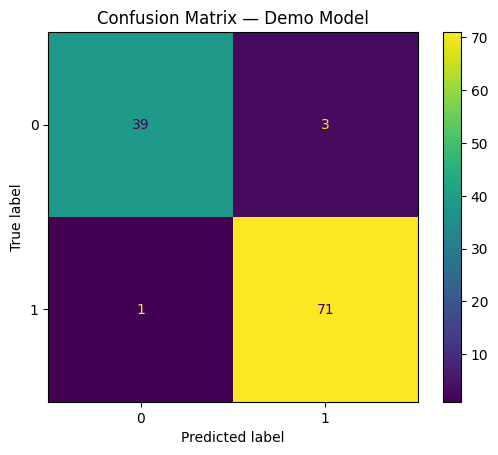

In [ ]:
acc = accuracy_score(y_test_d, preds_demo)
prec = precision_score(y_test_d, preds_demo)
rec = recall_score(y_test_d, preds_demo)
f1 = f1_score(y_test_d, preds_demo)

print(f'Accuracy:  {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall:    {rec:.3f}')
print(f'F1 score:  {f1:.3f}')

ConfusionMatrixDisplay.from_predictions(y_test_d, preds_demo)
plt.title('Confusion Matrix — Demo Model')
plt.show()

### 🔧 Your Turn — Evaluate your model

In [ ]:
# TODO: compute accuracy, precision, recall, and F1 for your model
acc_y = accuracy_score(y_test_y, preds_yours)
prec_y = precision_score(y_test_y, preds_yours)
rec_y = recall_score(y_test_y, preds_yours)
f1_y = f1_score(y_test_y, preds_yours)

print(f'Accuracy:  {acc_y:.3f}')
print(f'Precision: {prec_y:.3f}')
print(f'Recall:    {rec_y:.3f}')
print(f'F1 score:  {f1_y:.3f}')

ConfusionMatrixDisplay.from_predictions(y_test_y, preds_yours)
plt.title('Confusion Matrix — Your Model')
plt.show()

**For your assignment:** repeat this evaluation for your second model (`preds_yours_v2`) and compare the two in a sentence or two — which one had better precision/recall for your use case, and which would you recommend?

In [ ]:
# TODO (assignment): evaluate your second model the same way
acc_y2 = accuracy_score(y_test_y, preds_yours_v2)
prec_y2 = precision_score(y_test_y, preds_yours_v2)
rec_y2 = recall_score(y_test_y, preds_yours_v2)
f1_y2 = f1_score(y_test_y, preds_yours_v2)

print(f'Accuracy:  {acc_y2:.3f}')
print(f'Precision: {prec_y2:.3f}')
print(f'Recall:    {rec_y2:.3f}')
print(f'F1 score:  {f1_y2:.3f}')

ConfusionMatrixDisplay.from_predictions(y_test_y, preds_yours_v2)
plt.title('Confusion Matrix — Your Second Model')
plt.show()

---
## Stage 6 — Deployment Decision

A model isn't deployed just because it "works" — it's deployed when its performance matches what the business can tolerate. Some questions a team would ask before shipping the demo model above:

- Is recall high enough that we're not missing too many malignant cases (a costly false negative here)?
- Is precision high enough that we're not flooding specialists with false alarms (a costly false positive)?
- Should this model make the final call, or route uncertain cases to a human (**human-in-the-loop**)?
- What score threshold (not just 0.5) minimizes the cost that matters most for this use case?

In [ ]:
# Demo: instead of a hard 0/1 prediction, look at predicted PROBABILITIES
# and see what happens if we lower the threshold for flagging 'malignant'
probs_demo = model_demo.predict_proba(X_test_d)[:, 1]  # probability of class 1 (benign)

threshold = 0.7  # try changing this and re-running
adjusted_preds = (probs_demo >= threshold).astype(int)

print(f'--- Threshold = {threshold} ---')
print(classification_report(y_test_d, adjusted_preds))

### 🔧 Your Turn — Make the deployment call
Answer these in the cell below:

1. Based on your metrics above, would you recommend deploying this model as-is? Why or why not?
2. Which metric (precision or recall) matters more for your problem, and does your model do well on it?
3. Would you want a human reviewing any of the model's decisions before they're acted on? Which ones?

**Your answers:**

1.
2.
3.

---
## In-class activity:

Upload a simple small screenshot of your results on your dataset to the In-class activity module.

## Assignment

**For your assignment:** try training other models (Decision Tree, Random Forest, or KNN) on the same `X_train_y` / `y_train_y` data, and compare its evaluation metrics to logistic regression in Stage 5.

Then Visualize and compare all the models and write your OWN thought as a couple of sentences on why you got the results you did.

In [ ]:
# Sample code for a decision Tree, Similarly you can find the code for other models.
from sklearn.tree import DecisionTreeClassifier

model_yours_v2 = DecisionTreeClassifier(random_state=42)
model_yours_v2.fit(X_train_y, y_train_y)

preds_yours_v2 = model_yours_v2.predict(X_test_y)
print('Second model trained. Example predictions:', preds_yours_v2[:10])